# Chapter 10.3 — Regression

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Parts 10.1 and 10.2 built and judged a model that predicts a **category**. This part does the same for a model that predicts a **number**: a straight line through ten house sales, read by its slope, judged by how much of the price variation it explains, and bounded by the data it was fitted on. The same method is then applied to a real dataset — 442 diabetes patients — with scikit-learn, and the homework asks questions of that dataset.

**In this chapter:** Correlation · The regression equation · Residuals and the best line · Reading the slope · R² · The residual plot · Extrapolation and causation · The diabetes patients · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Read a correlation** — say whether two numeric variables move together, in which direction and how strongly, and what the number does not say.
> - **Fit and read the line** — predicted price = a + b × area: what the slope and the intercept mean, and how to predict by substitution.
> - **Judge the fit** — read R² as the share of the variation the line explains, and the residual plot as the check on whether a line was the right model.
> - **Know the limits** — stay inside the range the line was fitted on, and keep a slope apart from a cause.



**Contents**

- **10.3.1 · The real-estate problem** — ten house sales, plotted
- **10.3.2 · Correlation** — whether two variables move together
- **10.3.3 · The regression equation** — the line, its residuals, and how the algorithm finds it
- **10.3.4 · Reading the fitted equation** — slope, intercept, and a prediction
- **10.3.5 · The quality of the line** — R², and the residual plot
- **10.3.6 · Where the line may be used** — extrapolation, causation, and more than one predictor
- **10.3.7 · A real dataset — the diabetes patients** — the same method with scikit-learn
- **10.3.8 · Glossary** — the terms of this part
- **10.3.9 · Homework** — the graded work, on the patients



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The **Try it** boxes are small ungraded challenges. The graded work is Section 10.3.9.

> **Continuing from Parts 10.1 and 10.2.** Supervised learning, its six-step workflow and the difference between predicting a category and a number were set out in Part 10.1 (and Chapter 9, Section 9.3.6). This part assumes them and goes straight to the model that predicts a number.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section Section 10.3.3 adds scikit-learn, the library that fits the line.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.3.1 · The real-estate problem

*ten house sales*

A real-estate agent wants to examine the relationship between a home's selling price and its size. Can the price be estimated from the size alone? Ten recent sales are the whole dataset of this part: for each house, the floor area in square feet and the price in thousands of dollars. Every number in Sections 10.3.1 to 10.3.6 traces back to these ten rows, so every one can be checked.

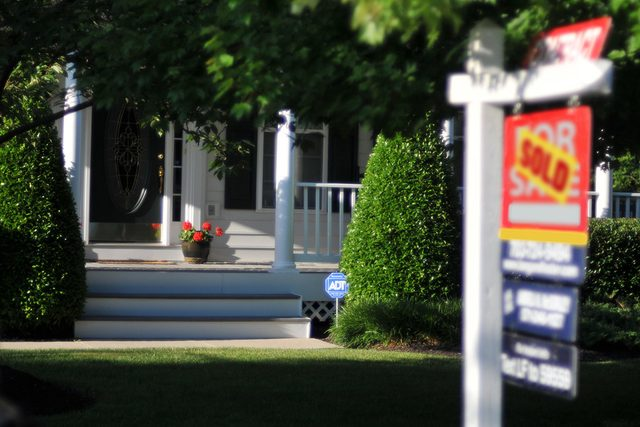

*Ten recent sales, each with a floor area and a price. The question is whether the second can be predicted from the first. — Photo: “House For Sale, Real Estate SOLD sign” by myguys.nova, CC BY — flickr.com*

- **x — area** is the **predictor**, or independent variable: the quantity that is known — the area (sq ft).
- **y — price** is the **response**, or dependent variable: the quantity to be estimated — the price ($1000s).
- Each row is one pair (x, y) — one point on the chart.



#### The steps

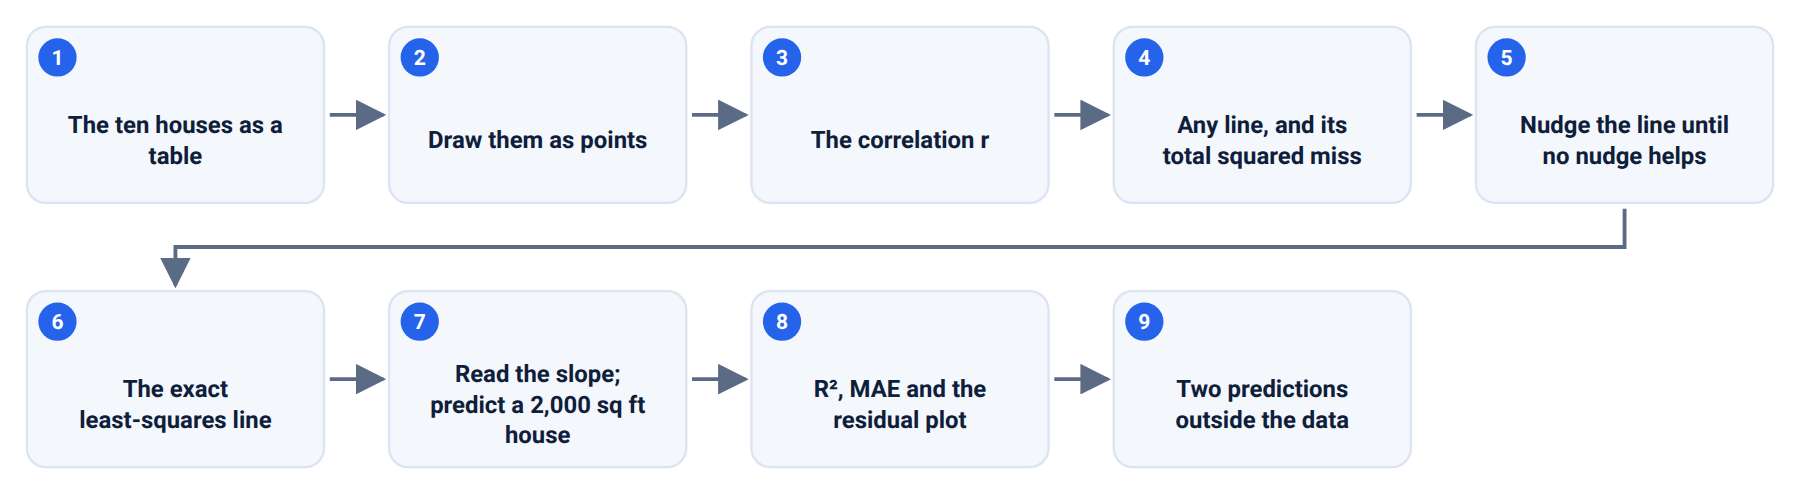

*The code walk of Sections 10.3.1 to 10.3.6.*



#### The ten houses

The ten sales go into a pandas table, one row per house, with the area and the price in thousands of dollars. Ten rows is small enough to check every later number by hand.



In [2]:
houses = pd.DataFrame({
    "area_sqft":   [1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700],
    "price_1000s": [ 245,  312,  279,  308,  199,  219,  405,  324,  319,  255],
})
houses

,area_sqft,price_1000s
0,1400,245
1,1600,312
2,1700,279
3,1875,308
4,1100,199
5,1550,219
6,2350,405
7,2450,324
8,1425,319
9,1700,255


#### The scatter plot

Each house is one point, area across and price up. Before any line is fitted, the picture shows what there is to learn: whether larger houses tend to sell for more, and how tightly.



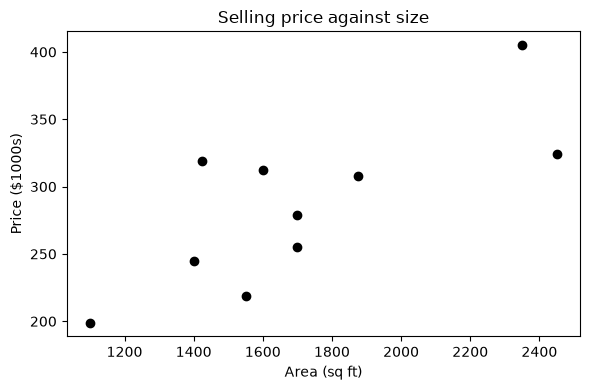

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(houses["area_sqft"], houses["price_1000s"], color="black")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("Selling price against size")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the points say:
>
> - **Bigger houses generally cost more** — the cloud rises from left to right.
> - **The relationship is not perfect** — the two houses of 1,700 sq ft sold for 279 and 255, and no straight line passes through every point.
> - **Of all the lines that could be drawn through this cloud, which one, and on what grounds?** That is the question of Section 10.3.3. Section 10.3.2 first asks whether there is a relationship to fit at all.



## 10.3.2 · Correlation

*whether two variables move together*

Before fitting a line, ask whether there is a relationship to fit. **Correlation** measures how two numeric variables move together, in one number $r$ between −1 and +1.

| Correlation | What it means | Examples |
|---|---|---|
| **Positive — r near +1** | As x goes up, y tends to go up. | Advertising spend and sales; house size and price. |
| **Negative — r near −1** | As x goes up, y tends to go down. | Driving speed and fuel economy; price and units sold. |
| **None — r near 0** | No straight-line relationship is visible. |  |

The sign of $r$ is the direction; how close it sits to ±1 is the strength. It measures a **straight-line** relationship only, and a strong correlation is not, on its own, a cause.



#### Three patterns

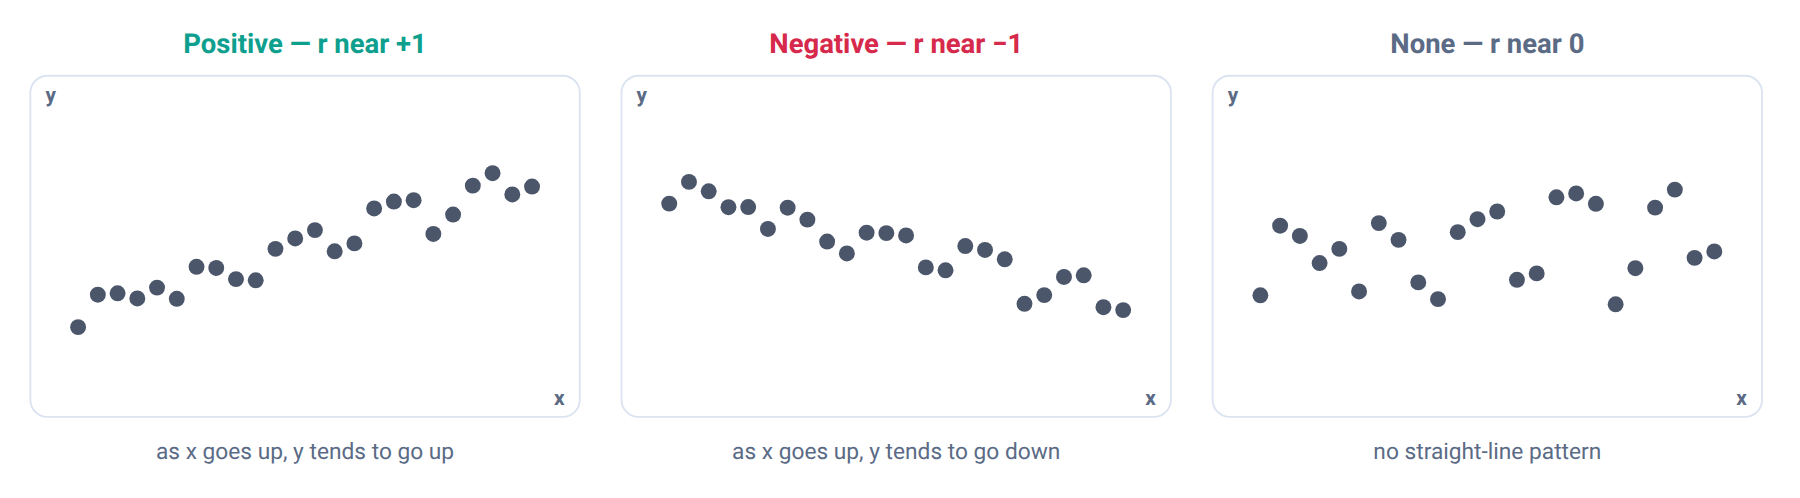

*Three clouds of points. The sign of r is the direction of the trend; how close r sits to +1 or −1 is how tightly the points follow a straight line.*

> **In the language of statistics.** For each house, $x_i - \bar{x}$ is how far its area sits above or below the average area, and $y_i - \bar{y}$ the same for its price. Multiply the two for each house and add the products: the sum is large and positive when bigger-than-average houses also cost more than average. Dividing by how much each variable varies on its own puts the result on a scale from −1 to +1: $$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\,\sqrt{\sum (y_i - \bar{y})^2}}$$ — the covariance of $x$ and $y$ divided by the two standard deviations. Section 10.3.5 meets $r$ again: its square is the share of the price variation a straight line can explain.



#### The correlation of area and price

`np.corrcoef` returns the correlation of every pair of its inputs as a small table — 1 on the diagonal (each variable with itself) and $r$ off it. The cell takes the off-diagonal entry and rounds it for display.

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\,\sqrt{\sum (y_i - \bar{y})^2}}$$

`np.corrcoef(x, y)` evaluates this formula and returns a 2 × 2 table; the off-diagonal entry is $r$.



> **Interpretation.** r = 0.762 for the ten houses.
>
> - **Positive**: area and price move together — larger houses sold for more, in this sample.
> - **Fairly strong**: close enough to 1 that a straight line is worth fitting.
> - **Its square, $r^2 = 0.58$**, is the share of the price variation that line will explain (Section 10.3.5).



In [4]:
r = np.corrcoef(houses["area_sqft"], houses["price_1000s"])[0, 1]
print("r =", round(float(r), 3))

r = 0.762


#### The sign of r

> **Try it.** Suppose the ten prices were replaced by the number of years each house took to sell, and the larger houses took longer. What sign would $r$ have, and would that make a straight line more or less appropriate than for price?
>
> *Answer.* Positive again: both quantities rise with area. The sign says nothing about whether a line is appropriate — only how close $r$ is to ±1 does, and the residual plot of Section 10.3.5 is the real check.



## 10.3.3 · The regression equation

*the line, its residuals, and how the algorithm finds it*

$$\text{predicted price} = a + b \times \text{area}$$

*Simple linear regression.* One independent variable, one dependent variable, one straight line. The model is this equation: put an area in, a predicted price comes out.

- **a — the intercept**: where the line starts, the predicted value when x is 0. Often it has no meaning of its own — no house has 0 square feet — it simply positions the line.
- **b — the slope**: how much the prediction changes when x rises by one unit. This is the number to read: it says what one more square foot, or one more baht of advertising, is worth.

The line will not pass through every point — real prices scatter around it. How far each point sits from the line is its **residual**:

$$\text{residual} = \text{actual} - \text{predicted}$$

*Residual.* One house's miss: what it sold for, minus what the line predicted. Positive when the house sold for more than the line says, negative when less.

Of all the lines that could be drawn, regression takes the one that sits **closest to the points overall** — the one whose residuals are smallest taken together. Each miss is squared, so that a miss of +20 no longer cancels a miss of −20 and one large miss counts for more than several small ones, and the squares are added up: one number for how wrong a line is. The best line is the one that makes that total smallest.



#### How the line is found

Of all the lines that could be drawn, the one with the smallest total squared miss is the fit. It does not have to be searched for: there is a direct formula, and it is what every regression library computes. The cells below hand the job to scikit-learn.

> **In the language of statistics.** The slope is $b = \sum (x_i - \bar{x})(y_i - \bar{y}) \big/ \sum (x_i - \bar{x})^2$ — the covariance of area and price over the variance of area, the same numerator as $r$ — and the intercept is $a = \bar{y} - b\,\bar{x}$, which places the line through the point of averages. This is the **method of least squares**.



#### The houses as features and target

scikit-learn takes the features as a table with one column per feature and the target as a single column, so the area is written `houses[["area_sqft"]]` with double brackets — a one-column table, not a single column. The double bracket is the mistake to expect the first time.



> **Interpretation.** (10, 1) and (10,) — ten rows with one feature each, and ten prices. The features are always two-dimensional and the target one-dimensional, whether there is one feature or fifty.



In [5]:
area = houses["area_sqft"].to_numpy()
price = houses["price_1000s"].to_numpy()

X_area = houses[["area_sqft"]]      # a one-column table: 10 rows, 1 feature
y_price = houses["price_1000s"]     # the target, one value per row
X_area.shape, y_price.shape

((10, 1), (10,))

#### Fitting the line in one line

`LinearRegression()` makes an empty model and `.fit(features, target)` finds the least-squares line. The intercept comes back as `.intercept_` and the slopes as `.coef_`, one per feature — a list, because a model with several predictors has several slopes.



> **Interpretation.** a = 98.24833 and b = 0.10977: the line through the ten houses, found in one line of code. Section 10.3.4 reads what the two numbers mean.



In [6]:
from sklearn.linear_model import LinearRegression

house_line = LinearRegression().fit(X_area, y_price)
a_exact, b_exact = house_line.intercept_, house_line.coef_[0]
print(f"a = {a_exact:.5f}   b = {b_exact:.5f}")
print(f"predicted price = {a_exact:.5f} + {b_exact:.5f} × area")

a = 98.24833   b = 0.10977
predicted price = 98.24833 + 0.10977 × area


#### The line and the ten residuals

The fitted line is drawn through the points, and each residual is drawn as a dashed vertical segment from the house to the line (`plt.plot([x, x], [y, yhat])` draws a vertical line because the two x-coordinates are the same).



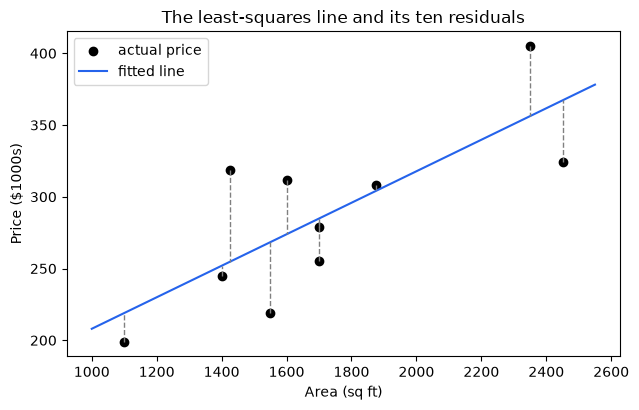

In [7]:
predicted = house_line.predict(X_area)
residuals = price - predicted

plt.figure(figsize=(6.5, 4.2))
plt.scatter(area, price, color="black", label="actual price")
x_line = np.linspace(area.min() - 100, area.max() + 100, 50)
plt.plot(x_line, a_exact + b_exact * x_line, color="#2563EB", label="fitted line")
for x, y, yhat in zip(area, price, predicted):
    plt.plot([x, x], [y, yhat], color="gray", linestyle="--", linewidth=1)    # one residual per house
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("The least-squares line and its ten residuals")
plt.legend()
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the picture shows:
>
> - **Each dashed segment is one residual** — the gap between a house's actual price and what the line predicts for its size. The two longest belong to the houses the line predicts worst.
> - **The line passes through the middle of the cloud** rather than favoring any one house: it is the line whose squared gaps add to the least.
> - **One house moved far enough would pull the whole line toward it** — which is why a single extreme value deserves a second look before the line is trusted.



## 10.3.4 · Reading the fitted equation

*slope, intercept, and a prediction*

$$\text{price} = 98.24833 + 0.10977 \times \text{area}$$

- **a = 98.25** — the intercept. No house has 0 sq ft, so it has no meaning of its own; it positions the line.
- **b = 0.1098** — the slope. Each extra square foot adds about \$110 to the predicted price (0.1098 thousand dollars). When x rises by one unit, the prediction rises by b.

> **The same reading, another business.** If a shop's model is predicted sales = 100 + 5 × advertising spend, then b = 5: each extra unit spent on advertising raises predicted sales by about 5 units. Spend 20 and the equation predicts $100 + 5 \times 20 = 200$. Reading the slope, and substituting a value, is the whole practice of using a regression.

> **A slope is not a cause.** The line says that larger houses in this sample sold for more. It does not say that adding a square foot to a house causes its price to rise by \$109.77. Section 10.3.6 returns to this.



#### Predicting a 2,000 sq ft house

Prediction is substitution: put the new area into the equation. None of the ten houses has 2,000 sq ft, so this is the line used for what it was fitted for. Prices are in thousands, so the cell also multiplies the answer back into dollars.

$$\text{predicted price} = 98.24833 + 0.10977 \times 2000$$



> **Interpretation.** 317.78 thousand dollars — about \$317,784. It is a prediction with an error attached: the residuals of Section 10.3.3 show real houses missing the line by up to 64 thousand dollars, and Section 10.3.5 turns that spread into a measure of how much to trust the number.



In [8]:
new_house = pd.DataFrame({"area_sqft": [2000]})
predicted_price = house_line.predict(new_house)[0]
print(f"0.10977 × 2000 = {b_exact * 2000:.2f}, plus 98.25 = {predicted_price:.2f} thousand dollars")
print(f"in dollars: ${predicted_price * 1000:,.0f}")

0.10977 × 2000 = 219.54, plus 98.25 = 317.78 thousand dollars
in dollars: $317,784


## 10.3.5 · The quality of the line

*R², and the residual plot*

$$R^{2} = \frac{\text{variation the line explains}}{\text{variation in } y \text{ altogether}}$$

*R-squared.* A share, so it runs from 0 to 1. **0** — the line does no better than guessing the average price for every house. **1** — the line passes through every point.

R² answers how much of the ups and downs in price this line accounts for. The rest is everything the line cannot see — the street, the condition, the year.

> **In the language of statistics.** The variation in $y$ altogether is the total squared miss of the flat line at the average, $\sum (y_i - \bar{y})^2$ — Section 10.3.3's starting point, 32,600. The variation the line leaves unexplained is its own total squared miss, $\sum (y_i - \hat{y}_i)^2 = 13{,}665.6$. So $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} = 1 - \frac{13{,}665.6}{32{,}600} = 0.581.$$ For a straight line fitted by least squares this is exactly the square of the correlation: $r^2 = 0.762^2 = 0.581$. Two other numbers are sometimes reported beside it — the MAE and the RMSE, both measuring the typical size of a miss rather than a share of variation — optional for this course and covered as a short aside below.



#### R² of the ten-house line

For a regression model `.score(features, target)` returns R². The cell prints it beside the square of $r$ from Section 10.3.2.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$



> **Interpretation.** 0.581: size explains about 58% of what makes these ten prices differ, and the other 42% is everything the line cannot see. The square of the correlation gives the same 0.581.



In [9]:
r_squared = house_line.score(X_area, y_price)     # for a regression model, .score() is R²
print(f"R² = {r_squared:.3f}    (r² = {r ** 2:.3f})")

R² = 0.581    (r² = 0.581)


#### MAE and RMSE — optional, self-study

Not required for this course. Two more numbers are sometimes reported beside R²: the MAE (the average size of a miss) and the RMSE (the same idea, but a large miss counts for more) — both in thousands of dollars, for a reader who wants an error's size rather than a share of variation explained.



> **Interpretation.** About \$31,000 (MAE) and \$37,000 (RMSE) — typical error sizes, useful when a number needs to be quoted to a client, but not part of the required material.



In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(price, predicted)
rmse = mean_squared_error(price, predicted) ** 0.5
print(f"MAE  = {mae:.2f} thousand dollars")
print(f"RMSE = {rmse:.2f} thousand dollars")

MAE  = 31.04 thousand dollars
RMSE = 36.97 thousand dollars


#### A high R² is not a good model

> **Watch out.** R² only says how closely the line follows this sample. It says nothing about whether the relationship makes sense, whether an outlier is driving it, or whether the line will hold on new houses. The residual plot below asks the first question; Section 10.3.6 asks the others.



#### The residual plot

Plot each residual against its predicted value. For an adequate model the plot should look like structureless noise centered on zero — the line has taken out everything a line can. A pattern is the model saying it is wrong, in a way the R² number cannot.

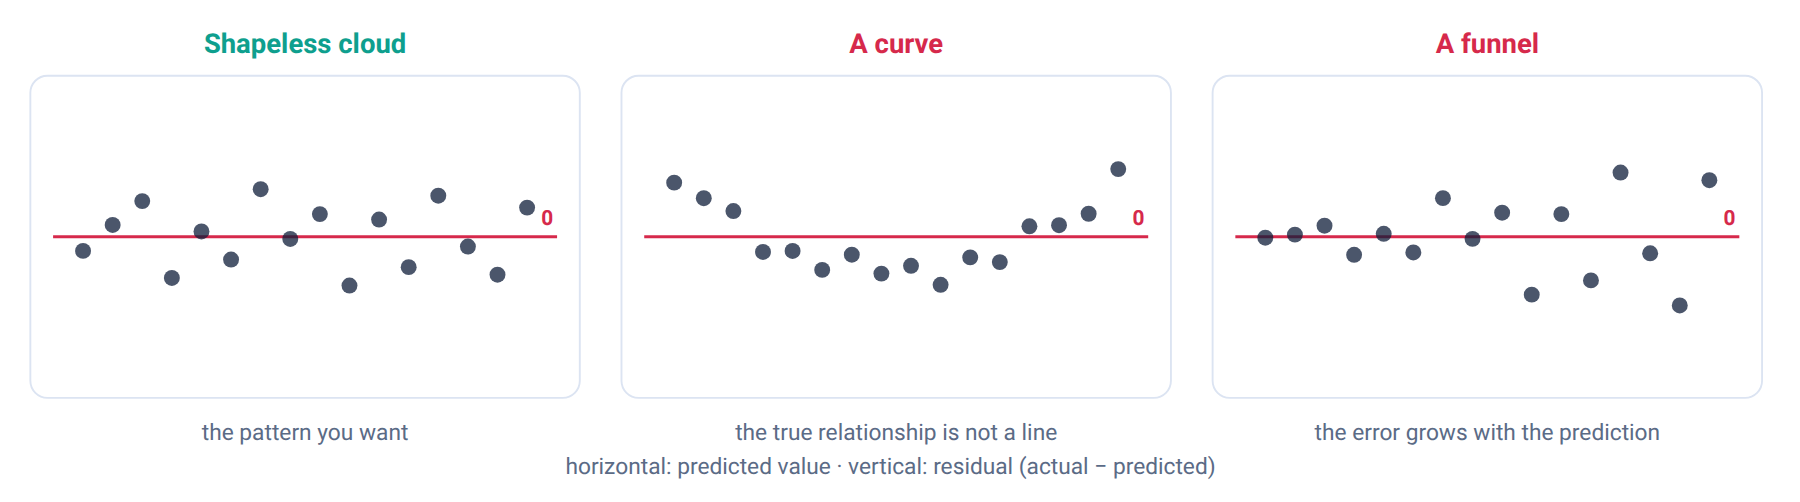

*Three residual plots. Only the first says the straight-line model is adequate; the other two are the model telling you it is wrong, in a way the R² number cannot.*

- **Noise around zero** — a line is adequate.
- **A curve or an arch** — the relationship is not straight, and a line is the wrong model however small its RMSE.
- **A widening spread** — the errors grow with the prediction, so no single RMSE describes them.



#### The residual plot of the ten houses

The ten residuals from Section 10.3.3 against the ten predicted prices — the predicted price ($1000s) across, the residual (actual − predicted) up — with a line at zero.



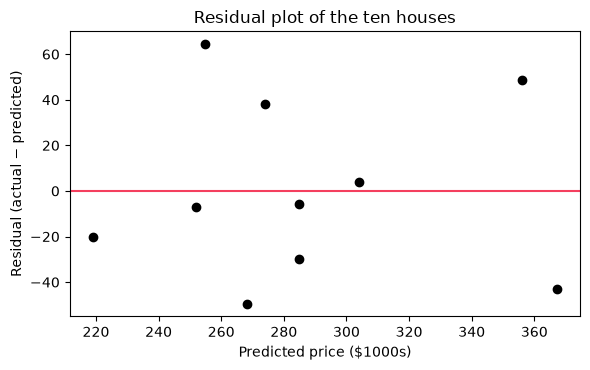

In [11]:
plt.figure(figsize=(6, 3.8))
plt.scatter(predicted, residuals, color="black")
plt.axhline(0, color="#F43F5E", linewidth=1.5)
plt.xlabel("Predicted price ($1000s)")
plt.ylabel("Residual (actual − predicted)")
plt.title("Residual plot of the ten houses")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the plot shows:
>
> - **The points sit on both sides of zero** with no curve and no funnel — as far as ten points can say, a straight line is the right shape.
> - **The residuals add to zero**, as the residuals of a least-squares line always do: the line runs through the middle of the cloud.
> - **Ten points is a small sample** for judging a shape; with the 442 patients of Section 10.3.7 the same plot says much more.



## 10.3.6 · Where the line may be used

*two limits, and more than one predictor*

> **Extrapolation.** The ten houses span 1,100 to 2,450 sq ft. The equation returns a price for a 12,000 sq ft house, or for 0 sq ft, but nothing in the data supports either. A fitted line is evidence only inside the range it was fitted on.

> **Causation.** Regression measures how two quantities move together. Ice-cream sales and drowning rates rise together; neither causes the other, and both follow the temperature. Only a designed experiment settles cause.



#### Two predictions outside the data

The same substitution as Section 10.3.4, at two areas no house in the sample comes near. The arithmetic works; the question is whether the answers mean anything.



> **Interpretation.** 98 thousand dollars for a house of no size, and 1.4 million for one five times larger than any in the sample. Both are the line continued past the data; neither is supported by it. Predictions are trusted inside 1,100 to 2,450 sq ft and treated as guesses outside.



In [12]:
for new_area in [0, 12000]:
    print(f"area {new_area:>6} sq ft  ->  predicted price {a_exact + b_exact * new_area:>8.1f} thousand dollars")
print(f"\nthe data covers {area.min()} to {area.max()} sq ft")

area      0 sq ft  ->  predicted price     98.2 thousand dollars
area  12000 sq ft  ->  predicted price   1415.5 thousand dollars

the data covers 1100 to 2450 sq ft


#### More than one predictor

$$\text{predicted price} = b_0 + b_1 \cdot \text{area} + b_2 \cdot \text{bedrooms} + b_3 \cdot \text{age}$$

*Multiple linear regression.* The same idea with several independent variables at once — **multiple linear regression**. Each $b$ is read the same way as the slope: the change in the prediction when that variable rises by one unit and the others stay put. The software finds the coefficients; Section 10.3.7 fits one.

Three cautions travel with any regression model, stated as things to check rather than as statistical tests:

- **Roughly a straight line** — regression draws lines. If the scatter curves, a line will miss in a pattern, and the residual plot shows it.
- **No extreme outliers** — one house at ten times the price pulls the whole line toward it. Look at the scatter before trusting the slope.
- **Stay inside the data** — the line is evidence only within the range it was fitted on.

> **Where Sections 10.3.1 to 10.3.6 leave us.** A line was fitted, read, judged and bounded — the same four steps the tree went through in Parts 10.1 and 10.2, with a number in place of a category. The rest of this part applies the same method to a real dataset with a library, so the homework can ask questions of it.



## 10.3.7 · A real dataset — the diabetes patients

*the same method with scikit-learn*

The dataset is a medical study bundled with scikit-learn: 442 diabetes patients, each measured at the start of the study — age, sex, body mass index (BMI), blood pressure and six blood-serum values — and one number measured a year later: a score for how far the disease had progressed. Higher is worse. The question is the real-estate question with a patient in place of a house.

> **The question.** Does a patient's body mass index predict how far the disease progresses in a year — and how much of the variation in progression does it explain? The predictor is BMI; the response is the progression score.

> **The library.** scikit-learn's `LinearRegression` fits the least-squares line of Section 10.3.3: `.fit(X, y)` finds a and b, `.intercept_` and `.coef_` hold them, `.predict()` substitutes new values, and `.score(X, y)` is R². The features go in as a table with one column per predictor, which is what lets the same call fit several predictors at once.



#### The steps

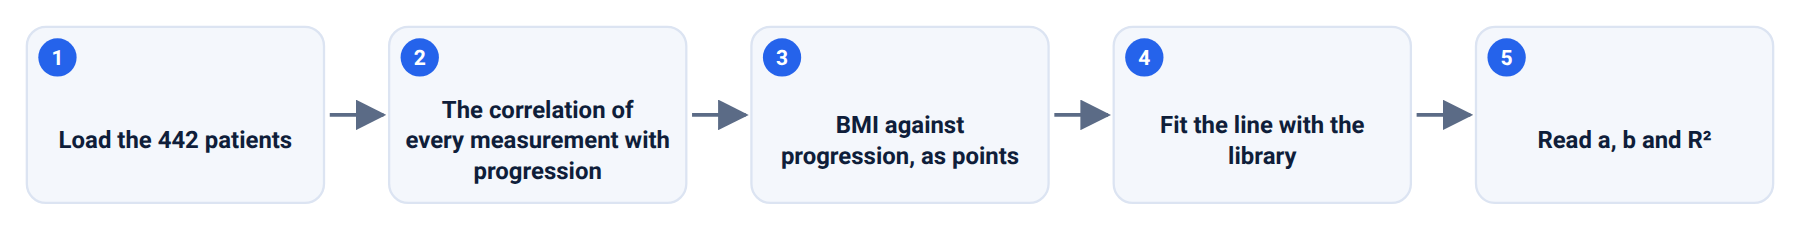

*The patient walk. The homework in Section 10.3.9 continues from here.*



#### Loading the patients

`load_diabetes(as_frame=True, scaled=False)` returns the measurements in their original units — BMI in kg/m², blood pressure in mm Hg — and the progression score as the target. The cell puts both in one table and shows the first rows.



> **Interpretation.** 442 rows and 11 columns: ten measurements at the start of the study and the progression score a year later. The columns s1 to s6 are blood-serum values; bmi and bp are body mass index and blood pressure.



In [13]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True, scaled=False)
patients = diabetes.data.copy()
patients["progression"] = diabetes.target
print("shape:", patients.shape)
patients.head()

shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


#### The correlation of every measurement with progression

Section 10.3.2 asked whether there is a relationship to fit. `.corr()` computes the correlation of every pair of columns; taking the progression column and sorting it ranks the ten measurements by how strongly each moves with the score.



> **Interpretation.** BMI has the strongest correlation with progression, about 0.59, with the serum value s5 close behind and blood pressure at 0.44. One serum value, s3, is negative: patients with more of it progressed less. None is as strong as the 0.76 of the ten houses.



In [14]:
patients.corr()["progression"].drop("progression").sort_values(ascending=False).round(3)

bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: progression, dtype: float64

#### BMI against progression

Each patient is one point: body mass index (kg/m²) across, disease progression (score) up — 442 points instead of ten.



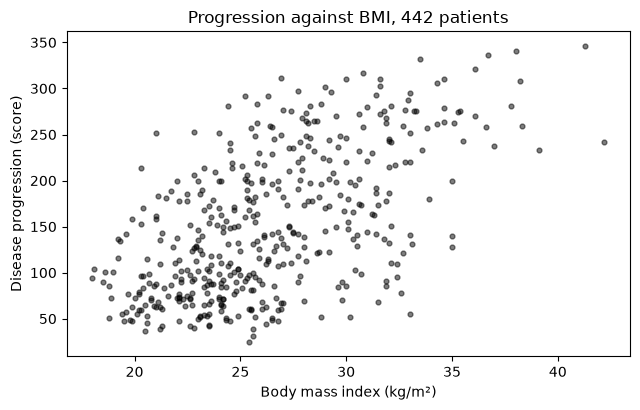

In [15]:
plt.figure(figsize=(6.5, 4.2))
plt.scatter(patients["bmi"], patients["progression"], s=12, color="black", alpha=0.5)
plt.xlabel("Body mass index (kg/m²)")
plt.ylabel("Disease progression (score)")
plt.title("Progression against BMI, 442 patients")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the points say:
>
> - **The cloud rises from left to right** — heavier patients tended to progress further — and it is a much looser cloud than the ten houses, as a correlation of 0.59 against 0.76 implies.
> - **The spread at any BMI is wide**: two patients with the same BMI can differ by 200 points. A line will explain part of the variation, not most of it.
> - **The BMI range runs from 18 to 42** — the range inside which the line about to be fitted may be used.



#### Fitting the line with the library

`LinearRegression().fit(X, y)` finds a and b by least squares. `X` must be a table, so the one predictor is passed as a one-column table. The cell prints the fitted equation.



> **Interpretation.** b = 10.23: each extra unit of BMI goes with about 10 more points of progression a year later. The intercept, −117.8, is the line's value at a BMI of 0 — no patient has that, so it positions the line and means nothing on its own, like the 98.25 of the houses.



In [16]:
from sklearn.linear_model import LinearRegression

X_bmi = patients[["bmi"]]                 # a one-column table, not a single column
y_prog = patients["progression"]
line = LinearRegression().fit(X_bmi, y_prog)
a_bmi, b_bmi = float(line.intercept_), float(line.coef_[0])
print(f"predicted progression = {a_bmi:.2f} + {b_bmi:.2f} × BMI")

predicted progression = -117.77 + 10.23 × BMI


#### R² of the BMI line

`.score(X, y)` is R², the share of the variation in progression the line explains; the square of the correlation should match it.



> **Interpretation.** 0.344: BMI explains about a third of the variation in progression, and two thirds is everything else the line cannot see — age, blood pressure, the serum values, and much that was never measured. The homework asks whether adding predictors closes that gap.



In [17]:
r_bmi = float(np.corrcoef(patients["bmi"], patients["progression"])[0, 1])
print(f"R² = {line.score(X_bmi, y_prog):.3f}    r = {r_bmi:.3f}, r² = {r_bmi ** 2:.3f}")

R² = 0.344    r = 0.586, r² = 0.344


#### From here

> **Key idea.** The ten houses and the 442 patients are the same problem: a number to predict, a straight line fitted by least squares, read by its slope and judged by R². The homework below continues with the patients: predictions inside and outside the data, the residual plot at a size where it speaks, a second predictor, and a model with several predictors at once. Chapter 11 leaves supervised learning behind: its data carry no answer column, and the task is to find groups in the rows without one.



## 10.3.8 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Predictor / response** | The known quantity x (independent variable) / the quantity to estimate y (dependent variable). |
| **Correlation r** | How two numeric variables move together, from −1 to +1; the sign is the direction, the size the strength of a straight-line relationship. |
| **Regression equation** | predicted y = a + b × x: the model itself. |
| **Intercept a** | The predicted value at x = 0; positions the line, often meaningless on its own. |
| **Slope b** | The change in the prediction when x rises by one unit — the number to read. |
| **Residual** | actual − predicted: one case's miss. |
| **Least squares** | Choosing the line whose squared residuals add to the least. |
| **R²** | The share of the variation in y the line explains, from 0 to 1; for a straight line, r². |
| **MAE / RMSE (optional)** | The typical size of a miss, in the units of y; the RMSE weighs large misses more. Not required for this course. |
| **Residual plot** | Residuals against predicted values; noise around zero means a line was the right shape. |
| **Extrapolation** | Predicting outside the range the line was fitted on — not supported by the data. |
| **Multiple linear regression** | The same equation with several predictors, each with its own coefficient. |



## 10.3.9 · Homework

*the graded work, on the patients*

The exercises continue Section 10.3.7 on the diabetes patients, in the order this part taught the ideas: predict by substitution, judge the fit, check the residual plot, respect the data's range, and widen the equation. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework dataset — the patients and the BMI line

*run this cell, but do not modify it*

Run this cell once and do not edit it. It reloads the 442 patients as `patients` and refits the BMI line of Section 10.3.7 as `line`, with `X_bmi` and `y_prog` as its inputs.



In [18]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

diabetes = load_diabetes(as_frame=True, scaled=False)
patients = diabetes.data.copy()
patients["progression"] = diabetes.target
X_bmi = patients[["bmi"]]
y_prog = patients["progression"]
line = LinearRegression().fit(X_bmi, y_prog)
print("patients:", patients.shape, "   BMI range:", patients["bmi"].min(), "to", patients["bmi"].max())
print(f"predicted progression = {line.intercept_:.2f} + {line.coef_[0]:.2f} × BMI")

patients: (442, 11)    BMI range: 18.0 to 42.2
predicted progression = -117.77 + 10.23 × BMI


#### Exercise 1 — Predict by substitution

Predict the progression score of a patient with a BMI of 25 and of one with a BMI of 35 — by hand from the equation, and with `line.predict(pd.DataFrame({"bmi": [25, 35]}))`. By how much do the two predictions differ, and how does that number follow from the slope?



In [19]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — R² in context

R² for the BMI line is 0.344. In one or two sentences, say what this tells a doctor about how much of a patient's disease progression BMI alone explains, and what the other 66% represents. Optional / self-study: compute the residuals of the BMI line for all 442 patients (`y_prog - line.predict(X_bmi)`) and their MAE, as in Section 10.3.5, and say how many points off the line is on a typical patient.



In [20]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The residual plot

Draw the residual plot of the BMI line: residuals against predicted values, with a line at zero, as in Section 10.3.5. Which of the three patterns does it show — noise around zero, a curve, or a widening spread — and what does that say about using a straight line here?



In [21]:
# YOUR CODE HERE (Exercise 3)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Inside and outside the data

The patients' BMI runs from 18 to 42. Predict the score for a BMI of 60 with the equation. Is this an extrapolation? Say why the number should not be reported, in the words of Section 10.3.6.



In [22]:
# YOUR CODE HERE (Exercise 4)

#### Your answer — Exercise 4

*Double-click this cell and type your answer here.*



#### Exercise 5 — A second predictor

Fit a second line with blood pressure (`patients[["bp"]]`) as the predictor. Report its slope and its R², and compare with the BMI line. Which single measurement predicts progression better, and how did the correlation table of Section 10.3.7 already tell you?



In [23]:
# YOUR CODE HERE (Exercise 5)

#### Your answer — Exercise 5

*Double-click this cell and type your answer here.*



#### Exercise 6 — More than one predictor

Fit a multiple regression with BMI and blood pressure together (`patients[["bmi", "bp"]]`) and report both coefficients and R². Then fit one with all ten measurements and report R². How much more of the variation do the extra predictors explain, and what does the coefficient of BMI mean now that blood pressure is in the equation?



In [24]:
# YOUR CODE HERE (Exercise 6)

#### Your answer — Exercise 6

*Double-click this cell and type your answer here.*



#### Bonus — one distant house

Return to the ten houses of Section 10.3.1. Remove the 2,450 sq ft house and refit the line with `LinearRegression`. How much does the slope change? Then put the house back and change its price to 600. What happens to the slope and to R², and which of the three cautions of Section 10.3.6 is this?



In [25]:
# YOUR CODE HERE (Bonus)

#### Your answer — the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime → Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

